In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [73]:
df = pd.read_csv(r'\Users\User\OneDrive\Desktop\python projects\Customer Churn Models\Telco_Customer_Churn_Dataset  (3).csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
df.info(
    
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [75]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [76]:
#Checking the dataset information, if the datatypes are right and the size of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
#Finding the null values in the dataset
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [78]:
#Calculating the total charges missing from the respective columns.
df.loc[df["TotalCharges"].isna(), "TotalCharges"] = (
    df["MonthlyCharges"] * df["tenure"]
)

In [79]:
#Checking for duplicates in the dataset.
df.duplicated().sum()

0

In [80]:
#Getting the summary statistics of the dataset.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Exploratory Data Analysis (EDA) is a crucial step in understanding the dataset and uncovering patterns, relationships, and insights. 
Here are some common EDA techniques that can be applied to the customer churn dataset:


In [81]:
#Calculating the customer churn rate in the dataset.
churn_rate = (df['Churn']=="Yes").mean()*100
f"Customer Churn Rate: {churn_rate:.2f}%"

'Customer Churn Rate: 26.54%'

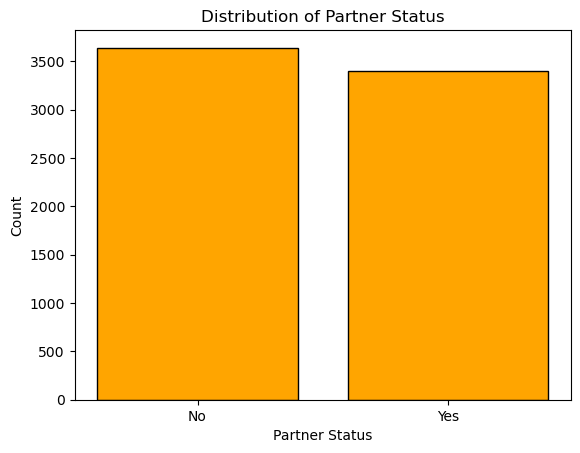

In [82]:
partner_status_counts = df['Partner'].value_counts()
plt.bar(partner_status_counts.index,partner_status_counts.values,edgecolor='black',color="orange")
plt.title('Distribution of Partner Status')
plt.xlabel('Partner Status')
plt.ylabel('Count')
plt.show()


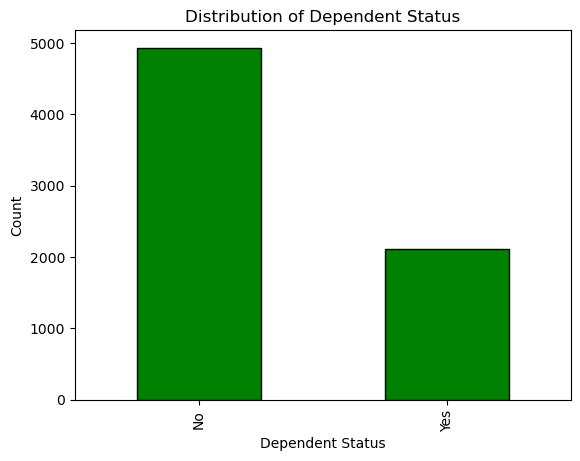

In [83]:

df['Dependents'].value_counts().plot(kind='bar', color='green', edgecolor='black')
plt.title('Distribution of Dependent Status')
plt.xlabel('Dependent Status')
plt.ylabel('Count')
plt.show()

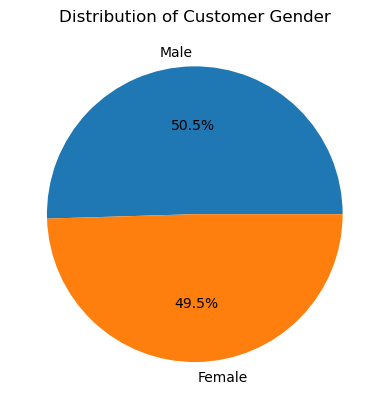

In [84]:
gender_counts= df['gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Customer Gender')
plt.show()


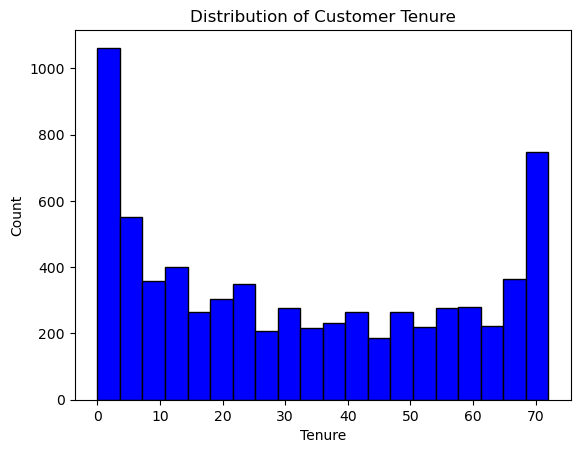

In [85]:
#Tenure distribution of customers
df['tenure'].hist(bins=20, color='blue', edgecolor='black',grid=False)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

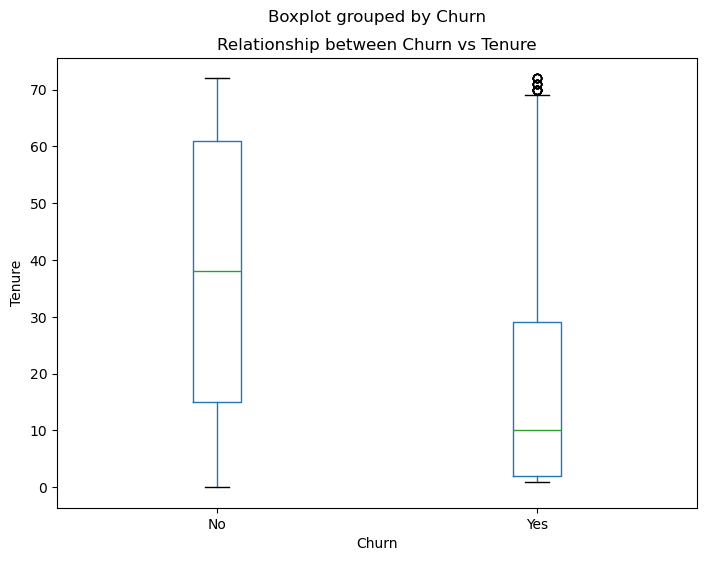

In [86]:
#Distribution of tenure based on churn status
df.boxplot(column='tenure', by='Churn', grid=False,figsize=(8,6))

plt.title('Relationship between Churn vs Tenure')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show();

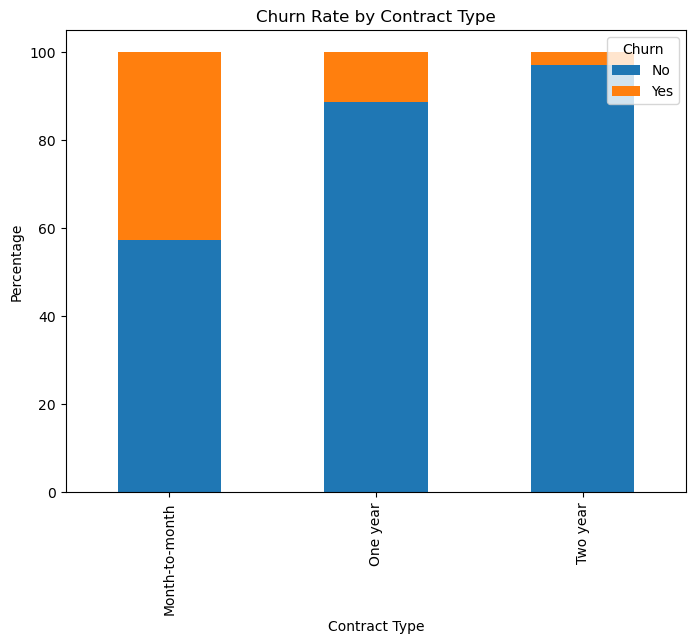

In [87]:
#Distribution of churn based on contract type
(
    pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100
).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn', loc='upper right')
plt.show()

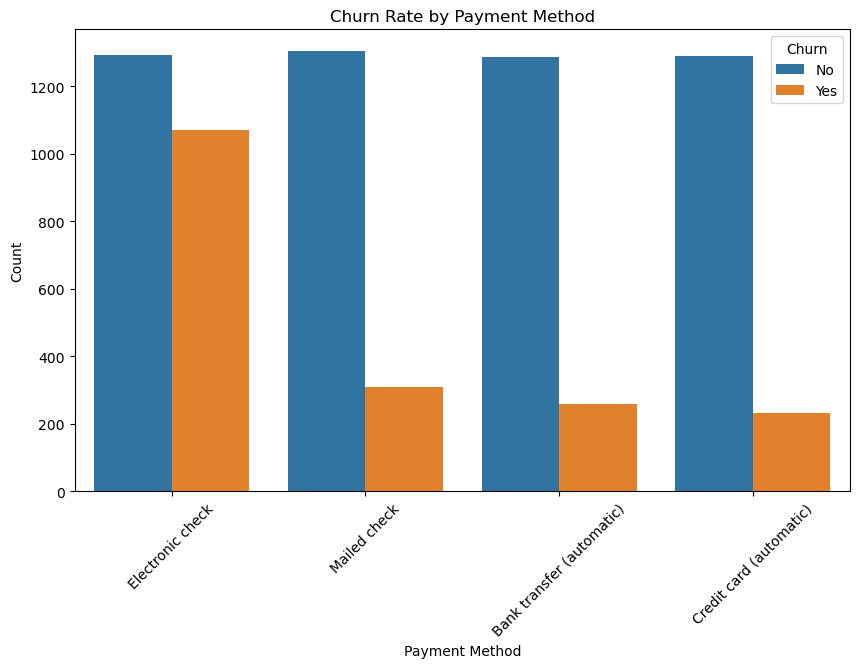

In [88]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='PaymentMethod',hue='Churn')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show();

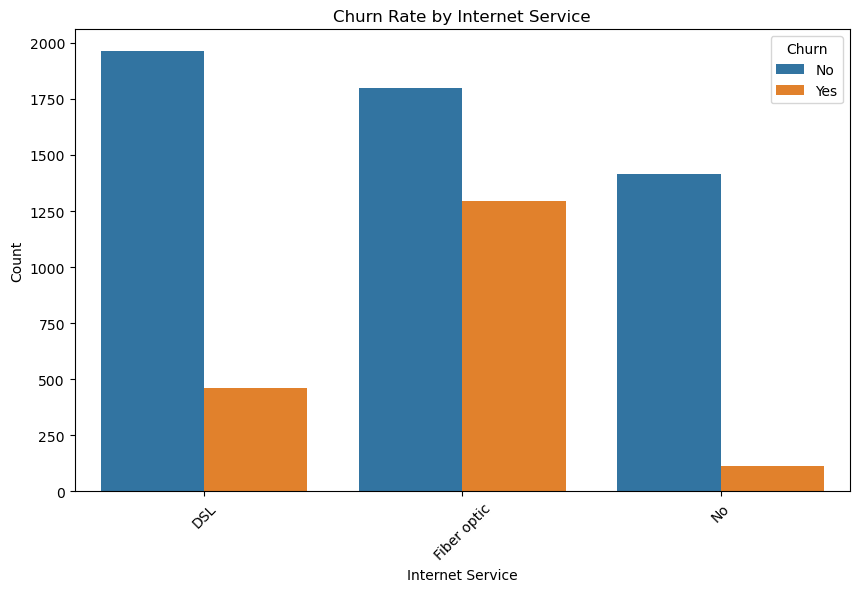

In [89]:
#Distribution of churn based on internet service type
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show();

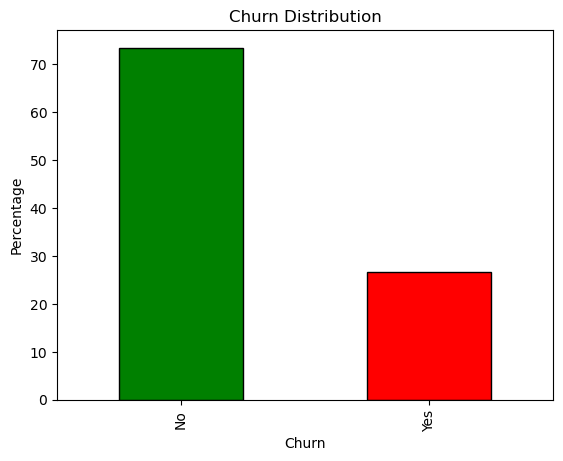

In [90]:
#Checking if the classification data is balanced or imbalanced by calculating the percentage of churned and non-churned customers in the dataset.
(df['Churn'].value_counts(normalize=True) * 100).plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Percentage')
plt.show()


# **Customer Segmentation Analysis on the churn Dataset.**

In [91]:
#Segmenting customers by tenure.
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12 Months","13-24 Months","25-48 Months","49-72 Months"]
)


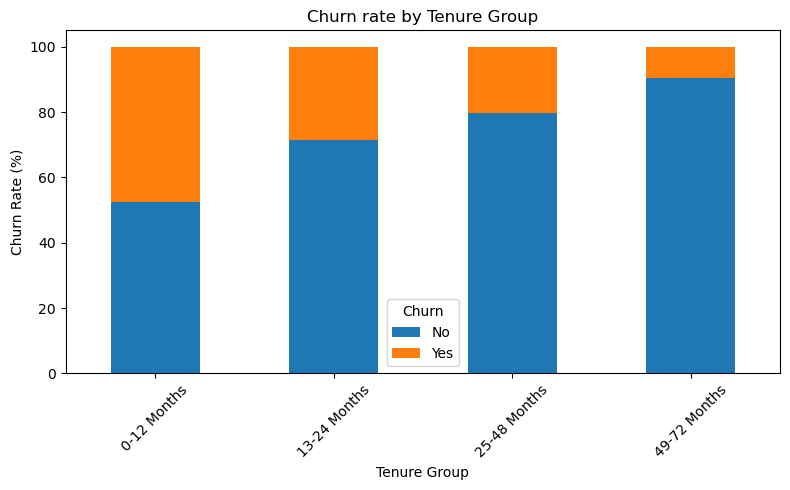

In [92]:
#Plotting the distribution of customers by tenure group.
(
    pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100
).plot(kind="bar", stacked=True, figsize=(8,5))
plt.title('Churn rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Segmentation by monthly charges**


In [93]:
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,40,70,100,130],
    labels=["Low","Medium","High","Very High"]
)

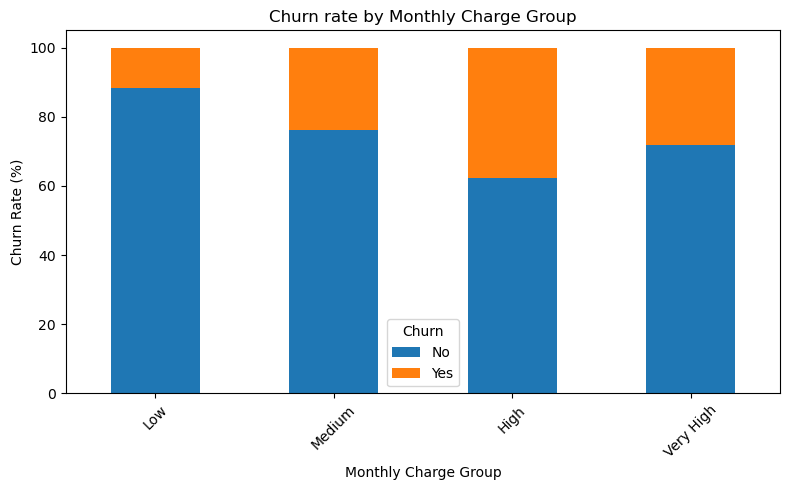

In [94]:
#Plotting the segmentation of customers by monthly charge group.

(
    pd.crosstab(df["MonthlyChargeGroup"], df["Churn"], normalize="index") * 100
).plot(kind="bar", stacked=True, figsize=(8,5))
plt.title('Churn rate by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Segmentation By Contract Type**

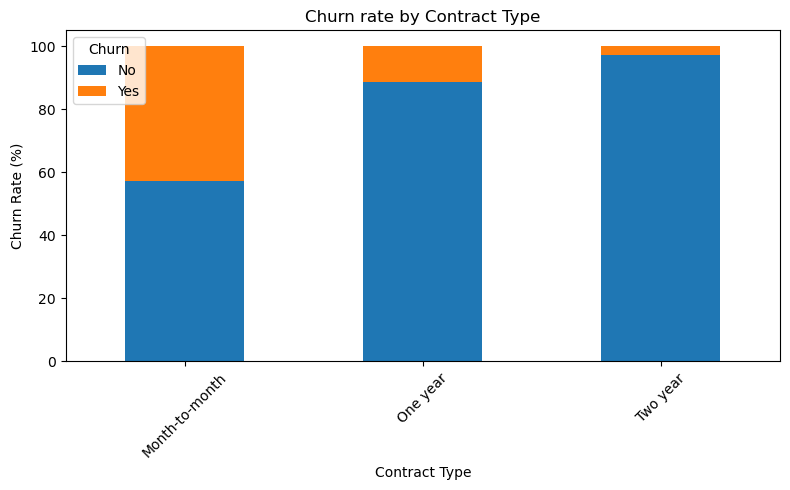

In [95]:
(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100).plot(kind="bar", stacked=True, figsize=(8,5))
plt.title('Churn rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
import warnings
warnings.filterwarnings("ignore")


In [97]:
segment = df.groupby(
    ["TenureGroup","Contract"]
)["Churn"].value_counts(normalize=True).mul(100).rename("Percentage")

print(segment)

TenureGroup   Contract        Churn
0-12 Months   Month-to-month  Yes       51.354062
                              No        48.645938
              One year        No        89.430894
                              Yes       10.569106
              Two year        No       100.000000
                              Yes        0.000000
13-24 Months  Month-to-month  No        62.279512
                              Yes       37.720488
              One year        No        91.878173
                              Yes        8.121827
              Two year        No       100.000000
                              Yes        0.000000
25-48 Months  Month-to-month  No        67.082294
                              Yes       32.917706
              One year        No        89.382239
                              Yes       10.617761
              Two year        No        97.810219
                              Yes        2.189781
49-72 Months  Month-to-month  No        73.976608
              

# ** Preparing the dataset for prediction.**

In [98]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,13-24 Months,High
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,49-72 Months,Very High
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0-12 Months,Low
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,0-12 Months,High
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,49-72 Months,Very High


In [99]:
#Drop unnecessary columns that are not needed for prediction.
df.drop(columns=["customerID","TenureGroup","MonthlyChargeGroup"], inplace=True)

In [100]:
#Splitting the dataset into features and target variable.
X = df.drop(columns=["Churn"])
y = df["Churn"]


In [101]:
#Encoding the target variable into binary format for model training.
y = y.map({
    "No":0,
    "Yes":1
})

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )


In [103]:
#Separating the features into numerical and categorical features for further analysis.
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(include="object").columns.tolist()

print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [104]:
#Building a preprocessing pipeline .

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat",OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features), 
    ]
)


In [105]:
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]
)


In [106]:
#Fitting the model on the training data.
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.9984025559105432

In [107]:
#Model accuracy on the test data.
model.score(X_test, y_test)

0.7920511000709723

In [108]:
#Checking the AUC score of the model on the test data.
model.predict_proba(X_test)[:,1]


array([0.71, 0.07, 0.01, ..., 0.  , 0.03, 0.41])

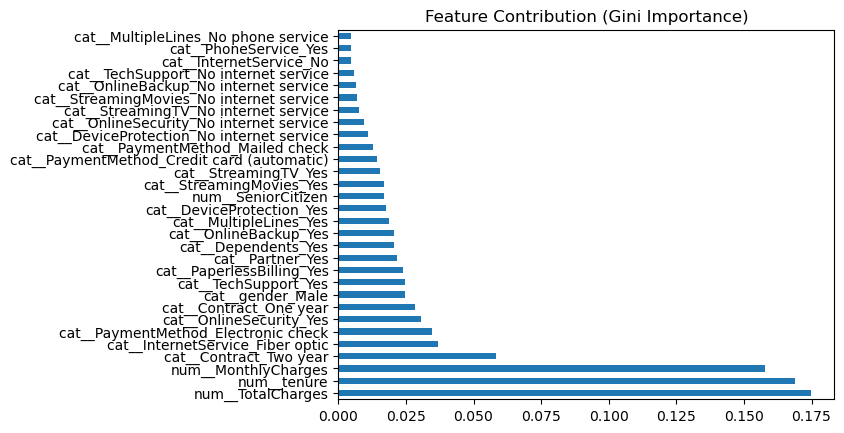

In [111]:
#Checking feature contributions using Gini importance from the Random Forest model.
rf = model.named_steps["classifier"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances =rf.feature_importances_

# Convert to a readable Pandas Series
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the contributions
feat_importances.plot(kind='barh')
plt.title('Feature Contribution (Gini Importance)')
plt.show()

In [ ]:
#Applying feature selection using the Random Forest model to select the most important features based on their contributions.
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=rf,
    prefit=True,
    threshold="median"      # You can also use "mean"
)

In [ ]:
#Transform the training and test data using the preprocessor.
X_train_processed = model.named_steps["preprocessor"].transform(X_train)
X_test_processed = model.named_steps["preprocessor"].transform(X_test)

In [ ]:
#Transform the training and test data using the selected features.
X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

In [ ]:
#Checking the shape of the processed and selected training data.
print(X_train_processed.shape)
print(X_train_selected.shape)


(5634, 30)
(5634, 15)


In [ ]:
#Training the model on the selected features after feature selection.
rf_selected = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_selected.fit(X_train_selected, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
#The classification results after the feature selection.
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_selected.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
#Classification results before the feature selection.
y_prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_prediction))
print(classification_report(y_test, y_prediction))

Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [122]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [127]:
#Build the pipeline with SMOTE and Gradient Boosting Classifier

model_xgb = ImbPipeline([
    ("preprocessor", preprocessor),

    ("smote", SMOTE(random_state=42)),

    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [129]:
#Fitting the model on the training data.
model_xgb=model_xgb.fit(X_train, y_train)
pred_y = model_xgb.predict(X_test)
print(classification_report(y_test, pred_y))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1036
           1       0.60      0.59      0.60       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [130]:
#Building xgboost pipeline with feature selection in it to select the most important features based on their contributions.
model_xgb2 = ImbPipeline([
    ("preprocessor", preprocessor),

    ("feature_selection",
     SelectFromModel(
         estimator=XGBClassifier(
             random_state=42,
             eval_metric="logloss"
         ),
         threshold="median"
     )),

    ("smote", SMOTE(random_state=42)),

    ("classifier",
     XGBClassifier(
         random_state=42,
         eval_metric="logloss"
     ))
])

In [131]:
#Fitting the model 2 of xgboost to the training data.
model_xgb2.fit(X_train, y_train)
print(classification_report(y_test, model_xgb2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.66      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [132]:
#Creating parameters for grid search to tune the hyperparameters of the XGBoost model 2 since it currently best performing.
param_grid = {
    "classifier__n_estimators": [100, 200, 300],

    "classifier__max_depth": [3, 5, 7],

    "classifier__learning_rate": [0.01, 0.05, 0.1],

    "classifier__subsample": [0.8, 1.0],

    "classifier__colsample_bytree": [0.8, 1.0],

    "classifier__min_child_weight": [1, 3, 5]
}

In [134]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model_xgb2,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [135]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          '...
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__learning_rate': [0.01, 0.05, 0.1],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__min_child_weight': [1, 3, 5],
                         'classifier__n_estimators': [100, 200, 300],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [136]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


In [137]:
print("Best F1 Score:")
print(grid_search.best_score_)

Best F1 Score:
0.6382911768968796


In [138]:
from sklearn.metrics import classification_report, accuracy_score

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7665010645848119
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1036
           1       0.54      0.78      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



The best model to choose is the tuned XGBoost model with feature selection and SMOTE applied.The reason is that:
Although the tuned XGBoost model achieved a slightly lower overall accuracy, it substantially improved recall and F1-score for the churn class.
 Since the primary objective of the project is to identify customers who are likely to churn, the tuned XGBoost model was selected as the final 
model because it correctly identified 78% of churning customers, outperforming the other models.

In [139]:
#Saving the model to a file for future use.
import joblib
joblib.dump(best_model, "Churn_model.pkl")


['Churn_model.pkl']